In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTAMOS LIBREARIAS PARA KMEANS

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

# GENERAMOS DATOS ALEATORIOS PARA EL EJEMPLO

In [4]:
X,y,c = make_blobs(500,cluster_std=0.8,centers=4,n_features=2,return_centers=True)

# CREO DATAFRAME CON CENTROIDES

In [5]:
df_blobs = pd.DataFrame(
    {
        'x1':X[:,0],
        'x2':X[:,1],
        'y':y
    }
)
df_blobs

,x1,x2,y
0,-5.926571,-3.360222,1
1,-6.116246,3.663105,2
2,-2.166341,-5.485195,3
3,5.182149,5.881910,0
4,-6.233124,4.449721,2
...,...,...,...
495,-5.611796,5.871253,2
496,-3.080243,-7.025857,3
497,-3.090322,-5.142285,3
498,-5.087628,5.076149,2


In [6]:
df_centers = pd.DataFrame(
    {
        'x1':c[:,0],
        'x2':c[:,1]
    }
)
df_centers

,x1,x2
0,6.267920,5.112847
1,-4.362284,-1.984919
2,-5.558750,5.288424
3,-2.781486,-6.052401


# GRAFICAMOS LOS DATOS

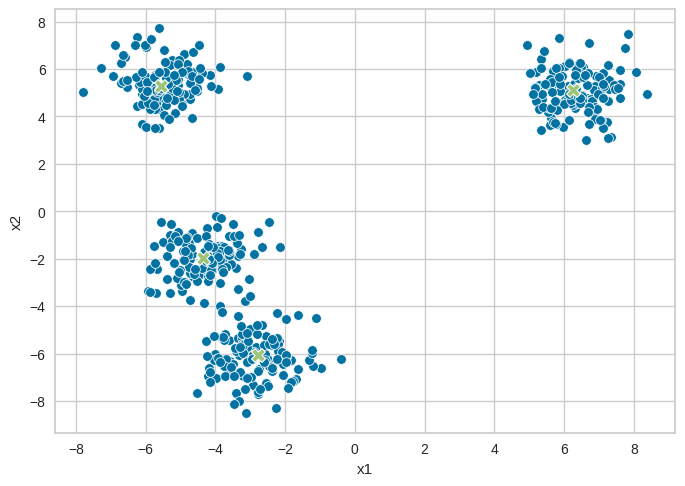

In [7]:
sns.scatterplot(data=df_blobs,x='x1',y='x2')
sns.scatterplot(data=df_centers,x='x1',y='x2',marker='X',s=100)
plt.show()

# APLICAMOS K-MEANS

In [8]:
kmeans = KMeans(n_clusters=4)
df_cluster = kmeans.fit_predict(X)
df_blobs['cluster'] = df_cluster
df_blobs

,x1,x2,y,cluster
0,-5.926571,-3.360222,1,3
1,-6.116246,3.663105,2,2
2,-2.166341,-5.485195,3,0
3,5.182149,5.881910,0,1
4,-6.233124,4.449721,2,2
...,...,...,...,...
495,-5.611796,5.871253,2,2
496,-3.080243,-7.025857,3,0
497,-3.090322,-5.142285,3,0
498,-5.087628,5.076149,2,2


In [9]:
k_means_centers = kmeans.cluster_centers_
df_k_means_center = pd.DataFrame(
    {
        'x1':k_means_centers[:,0],
        'x2':k_means_centers[:,1]
    }
)
df_k_means_center

,x1,x2
0,-2.856072,-6.196975
1,6.351342,5.070244
2,-5.490580,5.370255
3,-4.331292,-2.009579


# GRAFICAMOS LOS RESULTADOS DE K-MEANS

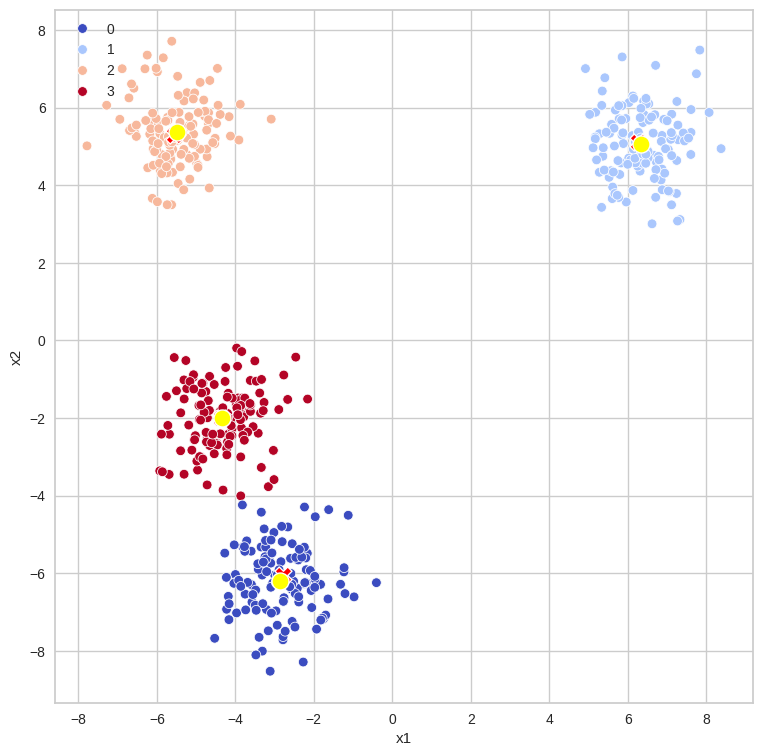

In [10]:
fig = plt.figure(figsize=(9,9))
sns.scatterplot(data=df_blobs,x='x1',y='x2',hue='cluster',palette='coolwarm')
sns.scatterplot(data=df_centers,  x='x1', y='x2', marker='X', s=150 , color='red')
sns.scatterplot(data=df_k_means_center,  x='x1', y='x2', marker='o', s=150 , color='yellow')
plt.show()

# VALIDAMOS EL MODELO

In [11]:
def vis_cluster(k):
    kmeans = KMeans(n_clusters=k)
    df_cluster = kmeans.fit_predict(X)
    df_blobs['cluster'] = df_cluster
    k_means_centers = kmeans.cluster_centers_
    df_k_means_center = pd.DataFrame(
        {
            'x1':k_means_centers[:,0],
            'x2':k_means_centers[:,1]

        }
    )
    fig = plt.figure(figsize=(9,9))
    sns.scatterplot(data=df_blobs,  x='x1', y='x2', hue= 'cluster', palette='coolwarm')
    sns.scatterplot(data=df_centers,  x='x1', y='x2', marker='X', s=150 , color='red')
    sns.scatterplot(data=df_k_means_center,  x='x1', y='x2', marker='o', s=150 , color='yellow')
    plt.show()

3


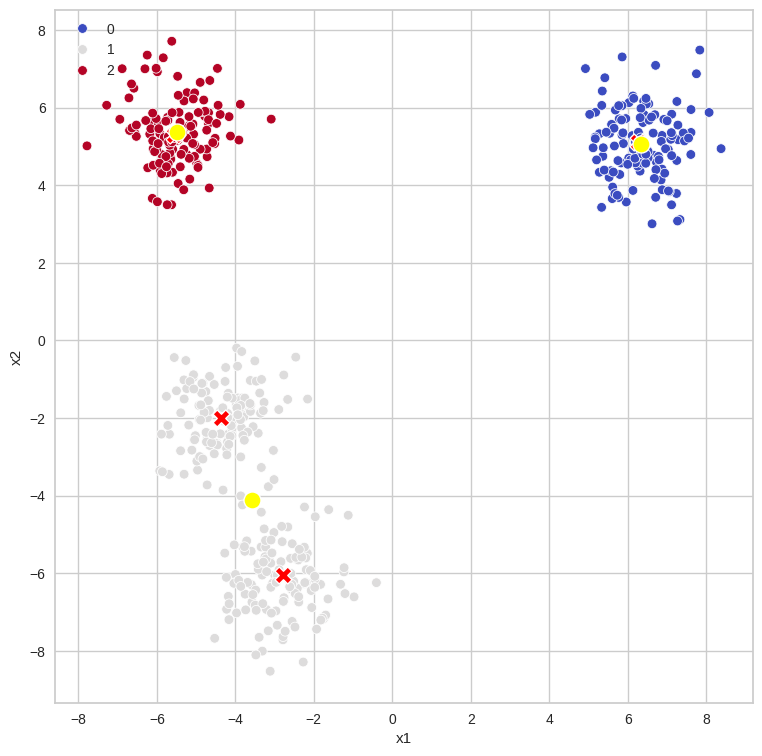

4


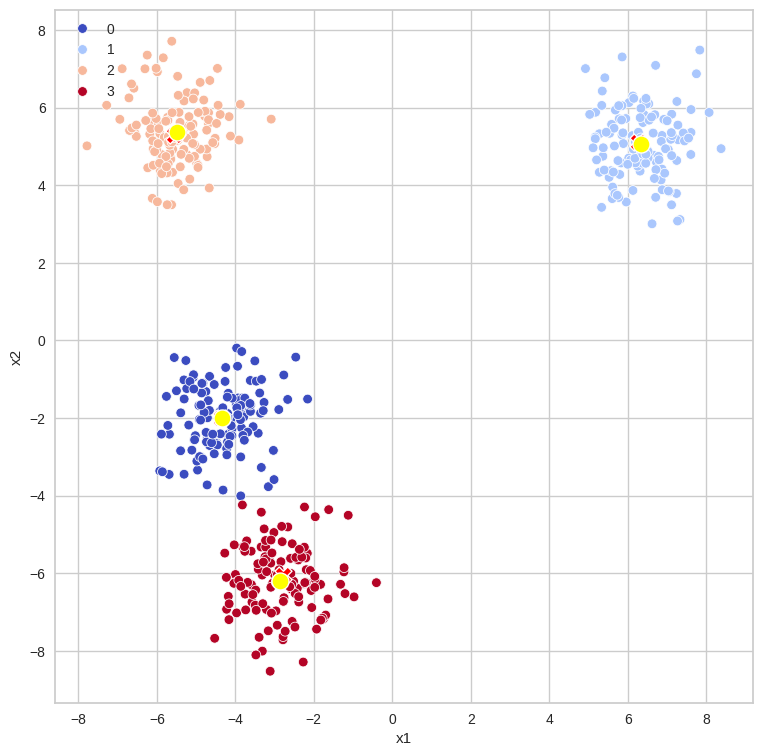

5


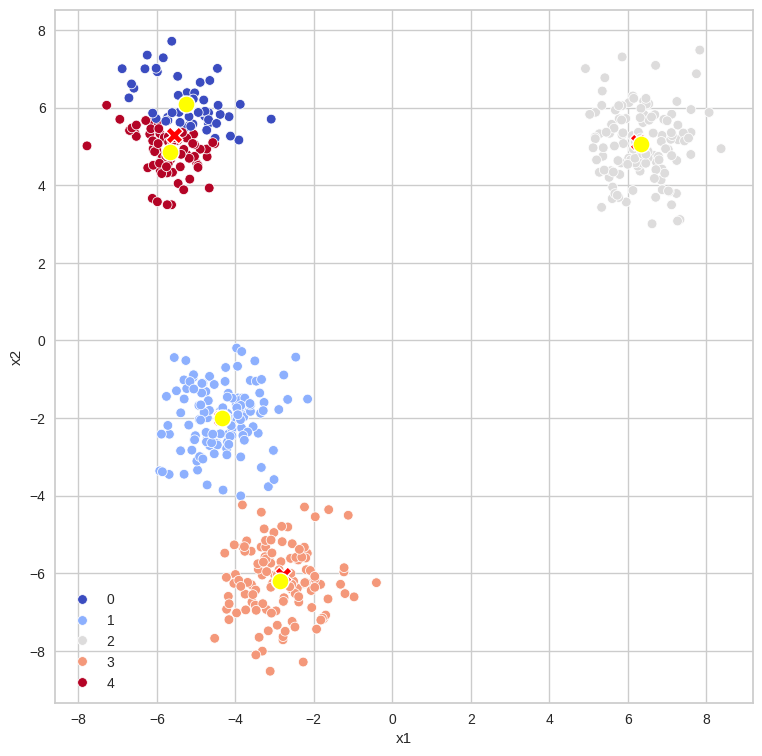

6


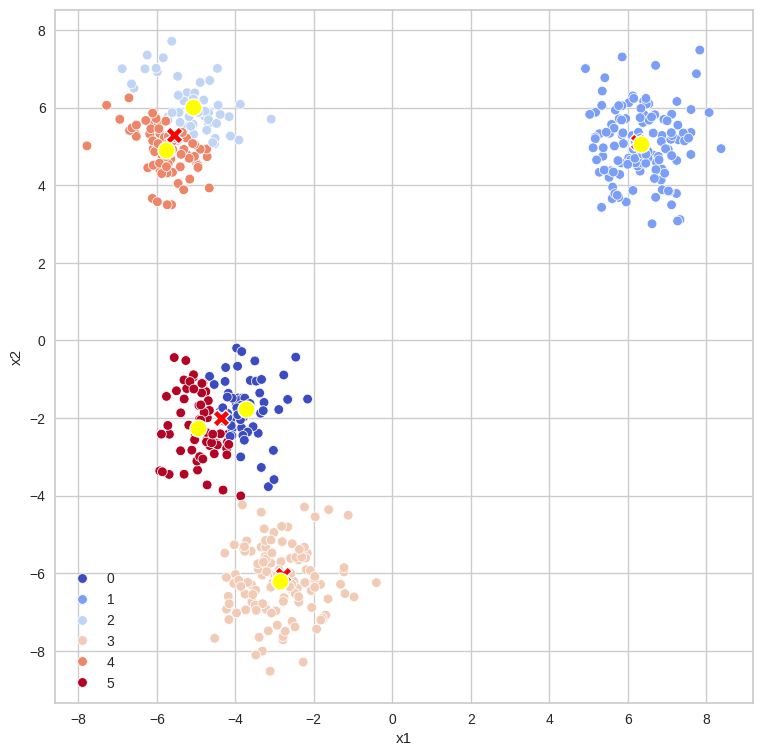

In [12]:
for _ in range(3,7):
    print(_)
    vis_cluster(_)

# ENCOTRAMOS EL VALOR IDEAL DE K

# UTILIZAMOS EL COEFICIENTE DE SILUETA

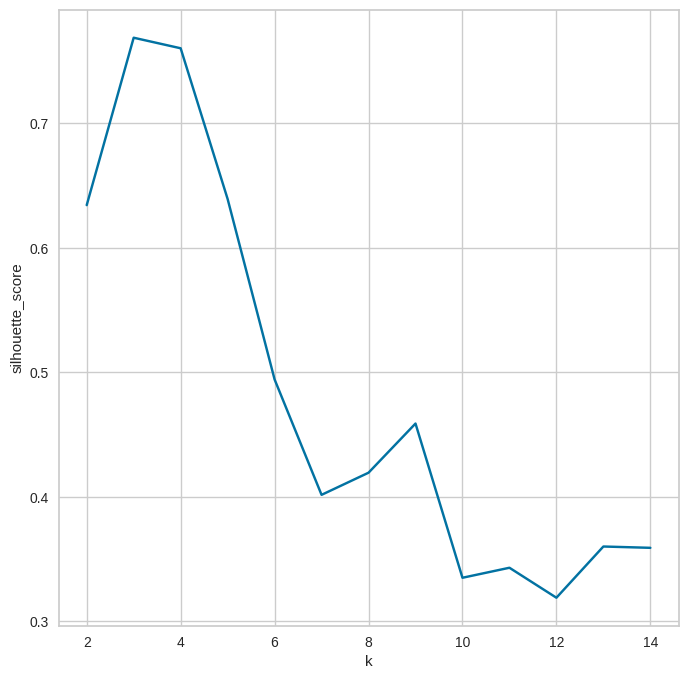

In [13]:
silhouette_scores = []
K = range(2,15)
for k in K:
  km = KMeans(n_clusters=k)
  km = km.fit(X)
  y = km.predict(X)
  silhouette_scores.append(silhouette_score(X,y))

plt.figure(figsize=(8,8))
plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('silhouette_score')
plt.show()

SilhouetteVisualizer(ax=<Axes: >, colors='yellowbrick',
                     estimator=KMeans(n_clusters=4))

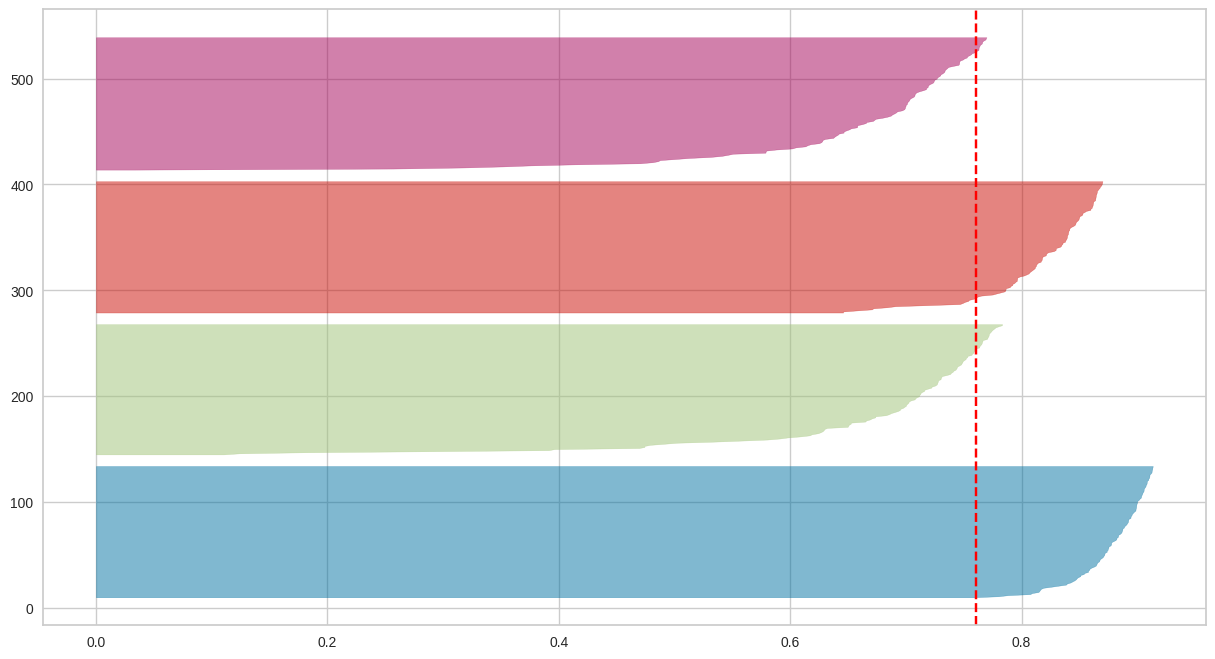

In [14]:
plt.figure(figsize=(15,8))
km = KMeans(n_clusters=4)
visualizer = SilhouetteVisualizer(km, colors='yellowbrick')
visualizer.fit(X)